In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
# Chargement du dataset nettoye (dataset_bretagne.csv, issu
# de l ETL) et import des librairies necessaires pour la
# preparation et l entrainement des modeles ML.
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RAW       = "../data/raw/"
PROCESSED = "../data/processed/"
FIGURES   = "../reports/figures/"
os.makedirs(FIGURES, exist_ok=True)

df = pd.read_csv(
    PROCESSED + "dataset_bretagne.csv",
    dtype={'code_commune': str, 'code_dept': str, 'code_insee': str}
)

print("Dataset charge :", df.shape)
print(df.columns.tolist())

Dataset charge : (2440, 30)
['code_commune', 'nom_commune', 'code_dept', 'annee', 'nb_inscrits', 'nb_votants', 'taux_abstention', 'score_ext_gauche', 'score_gauche', 'score_centre', 'score_droite', 'score_ext_droite', 'gagnant', 'code_insee', 'population', 'superficie_km2', 'densite', 'nb_associations_pour_mille', 'taux_chomage_2016', 'taux_chomage_2021', 'pct_sans_diplome_2016', 'pct_diplome_sup_2016', 'pct_sans_diplome_2021', 'pct_diplome_sup_2021', 'revenu_median_2016', 'revenu_median_2021', 'taux_criminalite_2016', 'taux_criminalite_2021', 'nb_entreprises_pour_mille_2016', 'nb_entreprises_pour_mille_2021']


In [3]:
# ============================================================
# TRANSFORMATION VERS LE FORMAT LARGE - dataset_final.csv
# ============================================================
# On transforme dataset_bretagne.csv (format long, 2440 lignes
# = 1233 communes 2017 + 1207 communes 2022) en 1 ligne par
# commune (dataset_final), en ne gardant que les communes
# presentes dans les DEUX annees (jointure interne).
#
# Colonnes produites :
#  - indicateurs statiques (population, superficie, densite,
#    vie associative) : identiques pour les deux annees
#  - indicateurs evolutifs en 2016 ET 2021 (deja presents
#    avec ces suffixes dans le dataset)
#  - scores electoraux 2017 ET 2022
#  - gagnant 2017 ET 2022
#  - deltas (2021 - 2016) pour chaque indicateur evolutif,
#    y compris pct_sans_diplome et pct_diplome_sup : la
#    nomenclature INSEE a ete corrigee dans l ETL, ces deltas
#    sont donc desormais coherents et utilisables.
#
# Ce dataset_final est le fichier de reference pour la suite :
# preparation ML (features = etat 2016 + scores 2017 + deltas,
# cible = gagnant_2022), tout en restant exploitable pour
# d autres analyses (il contient aussi l etat 2021/2022).
# ============================================================

INDICATEURS_STATIQUES = ['population', 'superficie_km2', 'densite', 'nb_associations_pour_mille']
INDICATEURS_EVOLUTIFS = ['taux_chomage', 'pct_sans_diplome', 'pct_diplome_sup',
                         'revenu_median', 'taux_criminalite', 'nb_entreprises_pour_mille']
SCORES_COLS = ['score_ext_gauche', 'score_gauche', 'score_centre', 'score_droite', 'score_ext_droite']

df_2017 = df[df['annee'] == 2017].set_index('code_insee')
df_2022 = df[df['annee'] == 2022].set_index('code_insee')

communes_communes = df_2017.index.intersection(df_2022.index)
print(f"Communes communes aux 2 annees : {len(communes_communes)}")

df_2017 = df_2017.loc[communes_communes]
df_2022 = df_2022.loc[communes_communes]

dataset_final = pd.DataFrame(index=communes_communes)
dataset_final.index.name = 'code_insee'

dataset_final['nom_commune'] = df_2017['nom_commune']
dataset_final['code_dept']   = df_2017['code_dept']

# Indicateurs statiques
for col in INDICATEURS_STATIQUES:
    dataset_final[col] = df_2017[col]

# Indicateurs evolutifs 2016, 2021 et leur delta
for ind in INDICATEURS_EVOLUTIFS:
    dataset_final[f'{ind}_2016'] = df_2017[f'{ind}_2016']
    dataset_final[f'{ind}_2021'] = df_2022[f'{ind}_2021']
    dataset_final[f'delta_{ind}'] = df_2022[f'{ind}_2021'] - df_2017[f'{ind}_2016']

# Scores 2017 et 2022
for score in SCORES_COLS:
    dataset_final[f'{score}_2017'] = df_2017[score]
    dataset_final[f'{score}_2022'] = df_2022[score]

# Gagnant 2017 et 2022
dataset_final['gagnant_2017'] = df_2017['gagnant']
dataset_final['gagnant_2022'] = df_2022['gagnant']

dataset_final = dataset_final.reset_index()

print(dataset_final.shape)
print(dataset_final.columns.tolist())
dataset_final.head()

Communes communes aux 2 annees : 1207
(1207, 37)
['code_insee', 'nom_commune', 'code_dept', 'population', 'superficie_km2', 'densite', 'nb_associations_pour_mille', 'taux_chomage_2016', 'taux_chomage_2021', 'delta_taux_chomage', 'pct_sans_diplome_2016', 'pct_sans_diplome_2021', 'delta_pct_sans_diplome', 'pct_diplome_sup_2016', 'pct_diplome_sup_2021', 'delta_pct_diplome_sup', 'revenu_median_2016', 'revenu_median_2021', 'delta_revenu_median', 'taux_criminalite_2016', 'taux_criminalite_2021', 'delta_taux_criminalite', 'nb_entreprises_pour_mille_2016', 'nb_entreprises_pour_mille_2021', 'delta_nb_entreprises_pour_mille', 'score_ext_gauche_2017', 'score_ext_gauche_2022', 'score_gauche_2017', 'score_gauche_2022', 'score_centre_2017', 'score_centre_2022', 'score_droite_2017', 'score_droite_2022', 'score_ext_droite_2017', 'score_ext_droite_2022', 'gagnant_2017', 'gagnant_2022']


,code_insee,nom_commune,code_dept,population,superficie_km2,densite,nb_associations_pour_mille,taux_chomage_2016,taux_chomage_2021,delta_taux_chomage,...,score_gauche_2017,score_gauche_2022,score_centre_2017,score_centre_2022,score_droite_2017,score_droite_2022,score_ext_droite_2017,score_ext_droite_2022,gagnant_2017,gagnant_2022
0,22001,Allineuc,22,588.0,24.0,25.1,33.557047,7.456824,7.117357,-0.339467,...,22.38,23.50,22.95,26.23,23.80,10.66,28.04,37.44,ext_droite,ext_droite
1,22002,Andel,22,1114.0,12.0,92.1,17.301038,6.445810,6.427328,-0.018482,...,24.63,27.69,33.78,39.15,18.30,4.79,20.86,27.57,centre,centre
2,22003,Aucaleuc,22,974.0,6.0,147.8,21.528525,9.403423,8.399250,-1.004173,...,32.38,35.23,24.73,20.45,9.07,1.37,29.89,40.55,gauche,ext_droite
3,22004,Bégard,22,4774.0,36.0,132.1,23.971895,13.742704,11.283909,-2.458795,...,34.78,32.23,24.21,24.56,11.42,3.87,26.14,36.60,gauche,ext_droite
4,22005,Belle-Isle-en-Terre,22,1034.0,14.0,73.1,33.980583,16.389549,10.289100,-6.100449,...,35.62,34.64,22.88,25.98,14.22,2.29,24.18,34.31,gauche,gauche


In [4]:
# ============================================================
# VERIFICATION ET SAUVEGARDE - dataset_final.csv
# ============================================================
# Avant de l utiliser pour le ML, on verifie :
# - l absence de valeurs manquantes
# - la coherence des deltas (notamment delta_pct_sans_diplome
#   et delta_pct_diplome_sup, corriges dans l ETL : ils doivent
#   maintenant avoir une distribution variee, sans biais
#   systematique identique sur toutes les communes)
# - la distribution de la cible gagnant_2022 (3 classes
#   attendues : ext_droite, centre, gauche)
#
# dataset_final.csv constitue le fichier de reference pour
# toute la suite (preparation ML, modeles, scenarios).
# ============================================================

print("Valeurs manquantes par colonne :")
print(dataset_final.isna().sum()[dataset_final.isna().sum() > 0])
print()

delta_cols = [c for c in dataset_final.columns if c.startswith('delta_')]
print("Statistiques des deltas :")
print(dataset_final[delta_cols].describe())
print()

print("Distribution gagnant_2017 :")
print(dataset_final['gagnant_2017'].value_counts())
print()
print("Distribution gagnant_2022 :")
print(dataset_final['gagnant_2022'].value_counts())

dataset_final.to_csv(PROCESSED + "dataset_final.csv", index=False)
print("\nSauvegarde : dataset_final.csv")

Valeurs manquantes par colonne :
Series([], dtype: int64)

Statistiques des deltas :
       delta_taux_chomage  delta_pct_sans_diplome  delta_pct_diplome_sup  \
count         1207.000000             1207.000000            1207.000000   
mean            -1.442469               -4.441257               3.392043   
std              2.492166                3.445911               3.077546   
min            -14.112554              -16.222775              -7.519564   
25%             -2.811555               -6.766578               0.663456   
50%             -1.375857               -4.671371               3.666047   
75%              0.008839               -1.773462               5.452372   
max             12.913714                6.369768              18.212421   

       delta_revenu_median  delta_taux_criminalite  \
count          1207.000000             1207.000000   
mean           2104.509528               -0.306277   
std             867.414956                5.088405   
min           

In [5]:
# ============================================================
# PREPARATION X / y ET SPLIT TRAIN/TEST
# ============================================================
# FEATURES (X) = ce qui est connu AVANT 2022 :
#  - indicateurs statiques (4) : population, superficie,
#    densite, vie associative
#  - indicateurs socio-eco 2016 (6) : etat de depart
#  - scores electoraux 2017 (5) : resultat precedent
#  - deltas 2016->2021 (6) : dynamique d evolution
#  => 21 features
#
# CIBLE (y) = gagnant_2022 (3 classes : ext_droite, centre,
# gauche). gagnant_2022 n apparait JAMAIS dans X.
#
# SPLIT : 80/20, aleatoire entre communes, stratifie sur y
# pour preserver la proportion des 3 classes dans train et
# test (utile car classes desequilibrees : 586/361/260).
# ============================================================

from sklearn.model_selection import train_test_split

FEATURES = (
    INDICATEURS_STATIQUES
    + [f'{ind}_2016' for ind in INDICATEURS_EVOLUTIFS]
    + [f'{score}_2017' for score in SCORES_COLS]
    + [f'delta_{ind}' for ind in INDICATEURS_EVOLUTIFS]
)

print(f"Nombre de features : {len(FEATURES)}")
print(FEATURES)

X = dataset_final[FEATURES]
y = dataset_final['gagnant_2022']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape}, Test : {X_test.shape}")
print("\nDistribution y_train :")
print(y_train.value_counts(normalize=True))
print("\nDistribution y_test :")
print(y_test.value_counts(normalize=True))

Nombre de features : 21
['population', 'superficie_km2', 'densite', 'nb_associations_pour_mille', 'taux_chomage_2016', 'pct_sans_diplome_2016', 'pct_diplome_sup_2016', 'revenu_median_2016', 'taux_criminalite_2016', 'nb_entreprises_pour_mille_2016', 'score_ext_gauche_2017', 'score_gauche_2017', 'score_centre_2017', 'score_droite_2017', 'score_ext_droite_2017', 'delta_taux_chomage', 'delta_pct_sans_diplome', 'delta_pct_diplome_sup', 'delta_revenu_median', 'delta_taux_criminalite', 'delta_nb_entreprises_pour_mille']

Train : (965, 21), Test : (242, 21)

Distribution y_train :
gagnant_2022
ext_droite    0.484974
centre        0.299482
gauche        0.215544
Name: proportion, dtype: float64

Distribution y_test :
gagnant_2022
ext_droite    0.487603
centre        0.297521
gauche        0.214876
Name: proportion, dtype: float64


In [6]:
# ============================================================
# ENCODAGE DE LA CIBLE ET STANDARDISATION DES FEATURES
# ============================================================
# ENCODAGE : LabelEncoder transforme gagnant_2022 (texte) en
# entiers (0/1/2). Necessaire pour la plupart des modeles
# sklearn. On garde le mapping pour pouvoir relire les
# resultats (matrices de confusion, etc.) avec les noms de
# groupes.
#
# STANDARDISATION : StandardScaler centre-reduit chaque
# feature (moyenne=0, ecart-type=1). Indispensable pour les
# modeles bases sur les distances ou le gradient (SVM, KNN,
# regression logistique). Le scaler est ajuste UNIQUEMENT sur
# X_train (regle d or : le test ne doit jamais influencer le
# scaler), puis applique a X_train et X_test.
# ============================================================

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encodage de la cible
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Classes encodees :")
for i, classe in enumerate(le.classes_):
    print(f"  {i} -> {classe}")

# Standardisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nX_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")
print(f"\nMoyenne X_train_scaled (doit etre ~0) : {X_train_scaled.mean():.4f}")
print(f"Ecart-type X_train_scaled (doit etre ~1) : {X_train_scaled.std():.4f}")

Classes encodees :
  0 -> centre
  1 -> ext_droite
  2 -> gauche

X_train_scaled : (965, 21)
X_test_scaled  : (242, 21)

Moyenne X_train_scaled (doit etre ~0) : -0.0000
Ecart-type X_train_scaled (doit etre ~1) : 1.0000


In [7]:
# ============================================================
# DEFINITION ET ENTRAINEMENT DES 5 MODELES
# ============================================================
# 5 algorithmes de classification, entraines sur les memes
# donnees standardisees (X_train_scaled / y_train_enc) :
#  - Random Forest
#  - Gradient Boosting
#  - Regression Logistique
#  - KNN
#  - SVM
#
# class_weight='balanced' est applique partout ou sklearn le
# permet (RF, LogReg, SVM), pour compenser le desequilibre
# des classes (48% / 30% / 22%). Gradient Boosting et KNN ne
# supportent pas ce parametre nativement dans sklearn ; le
# desequilibre etant modere, ce n est pas bloquant.
#
# Pour chaque modele on calcule :
#  - Accuracy et F1 (macro et weighted) sur le test
#  - Score de validation croisee (5-fold) sur le train
# F1 macro est important ici car il traite les 3 classes a
# egalite, contrairement a l accuracy brute qui favoriserait
# la classe majoritaire (ext_droite).
# ============================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score

models = {
    'Random Forest'        : RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    'Regression Logistique' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'KNN'                   : KNeighborsClassifier(n_neighbors=7),
    'SVM'                   : SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_enc)
    y_pred = model.predict(X_test_scaled)

    acc         = accuracy_score(y_test_enc, y_pred)
    f1_macro    = f1_score(y_test_enc, y_pred, average='macro')
    f1_weighted = f1_score(y_test_enc, y_pred, average='weighted')
    cv_scores   = cross_val_score(model, X_train_scaled, y_train_enc, cv=5, scoring='accuracy')

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
    }

    print(f"{name:25s} | Accuracy: {acc:.3f} | F1 macro: {f1_macro:.3f} | F1 weighted: {f1_weighted:.3f} | CV: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

Random Forest             | Accuracy: 0.789 | F1 macro: 0.767 | F1 weighted: 0.786 | CV: 0.765 +/- 0.018
Gradient Boosting         | Accuracy: 0.802 | F1 macro: 0.784 | F1 weighted: 0.800 | CV: 0.755 +/- 0.031
Regression Logistique     | Accuracy: 0.789 | F1 macro: 0.785 | F1 weighted: 0.790 | CV: 0.744 +/- 0.011
KNN                       | Accuracy: 0.715 | F1 macro: 0.675 | F1 weighted: 0.704 | CV: 0.693 +/- 0.027
SVM                       | Accuracy: 0.702 | F1 macro: 0.691 | F1 weighted: 0.706 | CV: 0.744 +/- 0.021


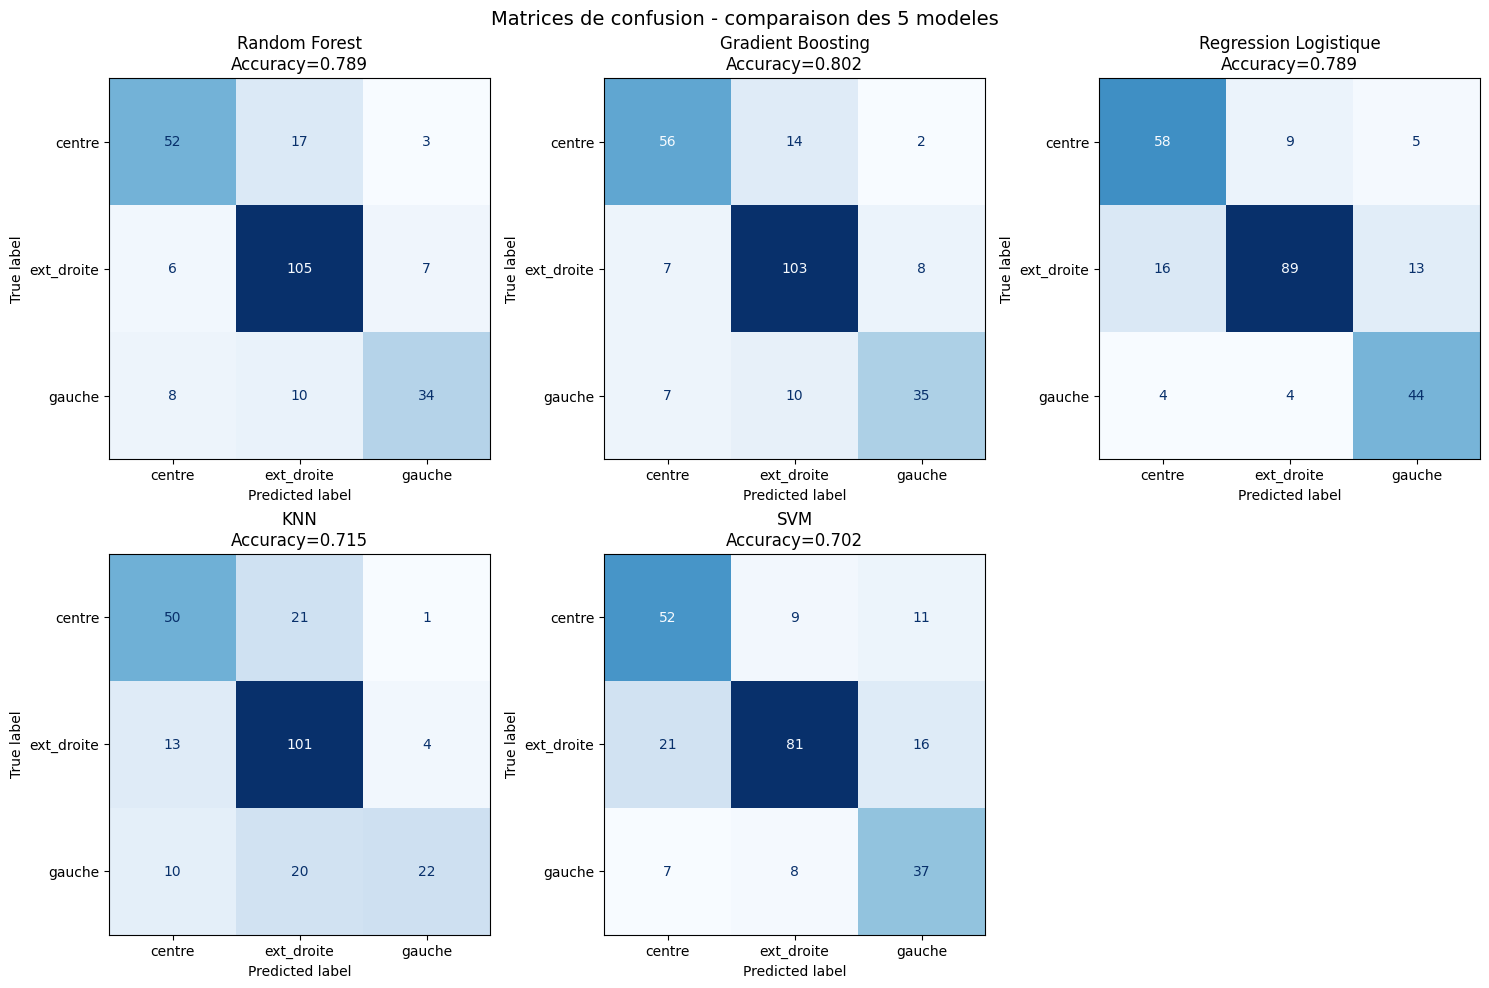

In [8]:
# ============================================================
# MATRICES DE CONFUSION - LES 5 MODELES
# ============================================================
# Pour chaque modele, la matrice de confusion montre, pour
# chaque vraie classe (ligne), comment les predictions se
# repartissent (colonnes). La diagonale = predictions
# correctes.
#
# Objectif : voir SI les erreurs sont concentrees sur une
# classe en particulier (ex: confusion centre <-> ext_droite)
# plutot que de se fier uniquement a l accuracy globale.
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test_enc, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{name}\nAccuracy={res['accuracy']:.3f}")

axes[-1].axis('off')

plt.suptitle("Matrices de confusion - comparaison des 5 modeles", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES + "07_matrices_confusion.png", dpi=150)
plt.show()

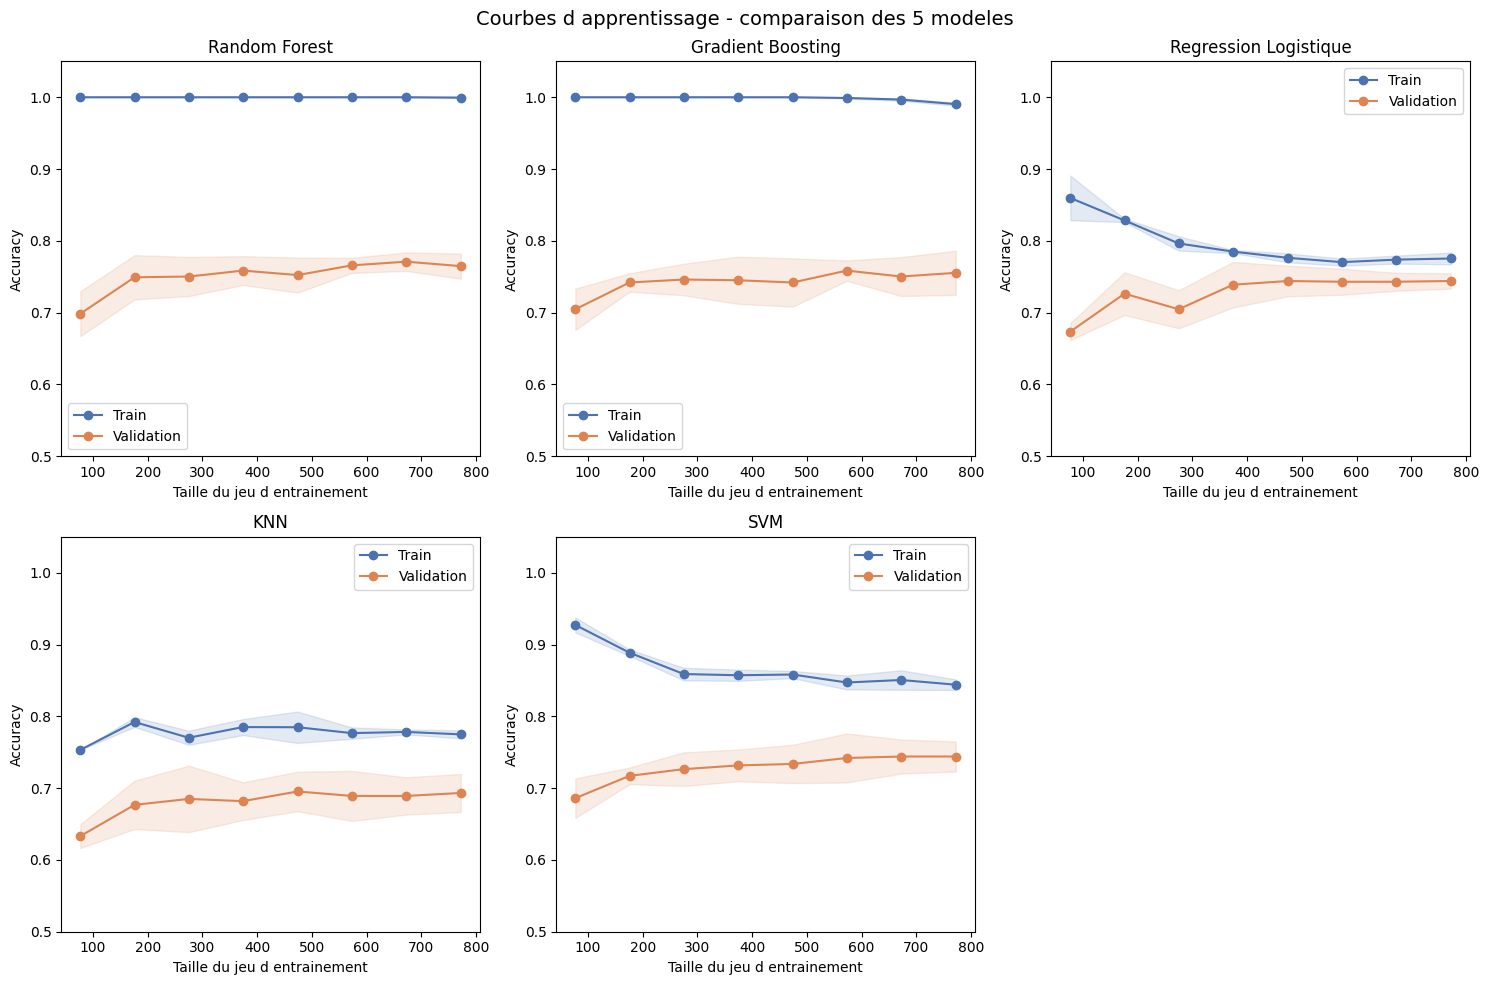

In [9]:
# ============================================================
# COURBES D APPRENTISSAGE - LES 5 MODELES
# ============================================================
# Pour chaque modele, learning_curve() entraine le modele sur
# des sous-ensembles croissants du train (10% a 100%), et
# mesure l accuracy sur le train ET sur une validation croisee
# a chaque taille.
#
# Lecture :
#  - Si les deux courbes convergent vers une valeur elevee :
#    bon equilibre biais/variance.
#  - Si la courbe train reste tres au-dessus de la courbe
#    validation (ecart large) : surapprentissage (overfitting).
#  - Si les deux courbes sont basses et proches : sous-
#    apprentissage (underfitting).
#
# Ces courbes justifient/valident les choix d hyperparametres
# (ex: max_depth limite pour RF/GB pour eviter l overfitting).
# ============================================================

from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

train_sizes = np.linspace(0.1, 1.0, 8)

for i, (name, res) in enumerate(results.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        res['model'], X_train_scaled, y_train_enc,
        train_sizes=train_sizes, cv=5, scoring='accuracy', random_state=42
    )

    axes[i].plot(train_sizes_abs, train_scores.mean(axis=1), 'o-', label='Train', color='#4C72B0')
    axes[i].plot(train_sizes_abs, val_scores.mean(axis=1), 'o-', label='Validation', color='#DD8452')
    axes[i].fill_between(train_sizes_abs,
                          train_scores.mean(axis=1) - train_scores.std(axis=1),
                          train_scores.mean(axis=1) + train_scores.std(axis=1),
                          alpha=0.15, color='#4C72B0')
    axes[i].fill_between(train_sizes_abs,
                          val_scores.mean(axis=1) - val_scores.std(axis=1),
                          val_scores.mean(axis=1) + val_scores.std(axis=1),
                          alpha=0.15, color='#DD8452')

    axes[i].set_title(name)
    axes[i].set_xlabel("Taille du jeu d entrainement")
    axes[i].set_ylabel("Accuracy")
    axes[i].legend()
    axes[i].set_ylim(0.5, 1.05)

axes[-1].axis('off')

plt.suptitle("Courbes d apprentissage - comparaison des 5 modeles", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES + "08_courbes_apprentissage.png", dpi=150)
plt.show()

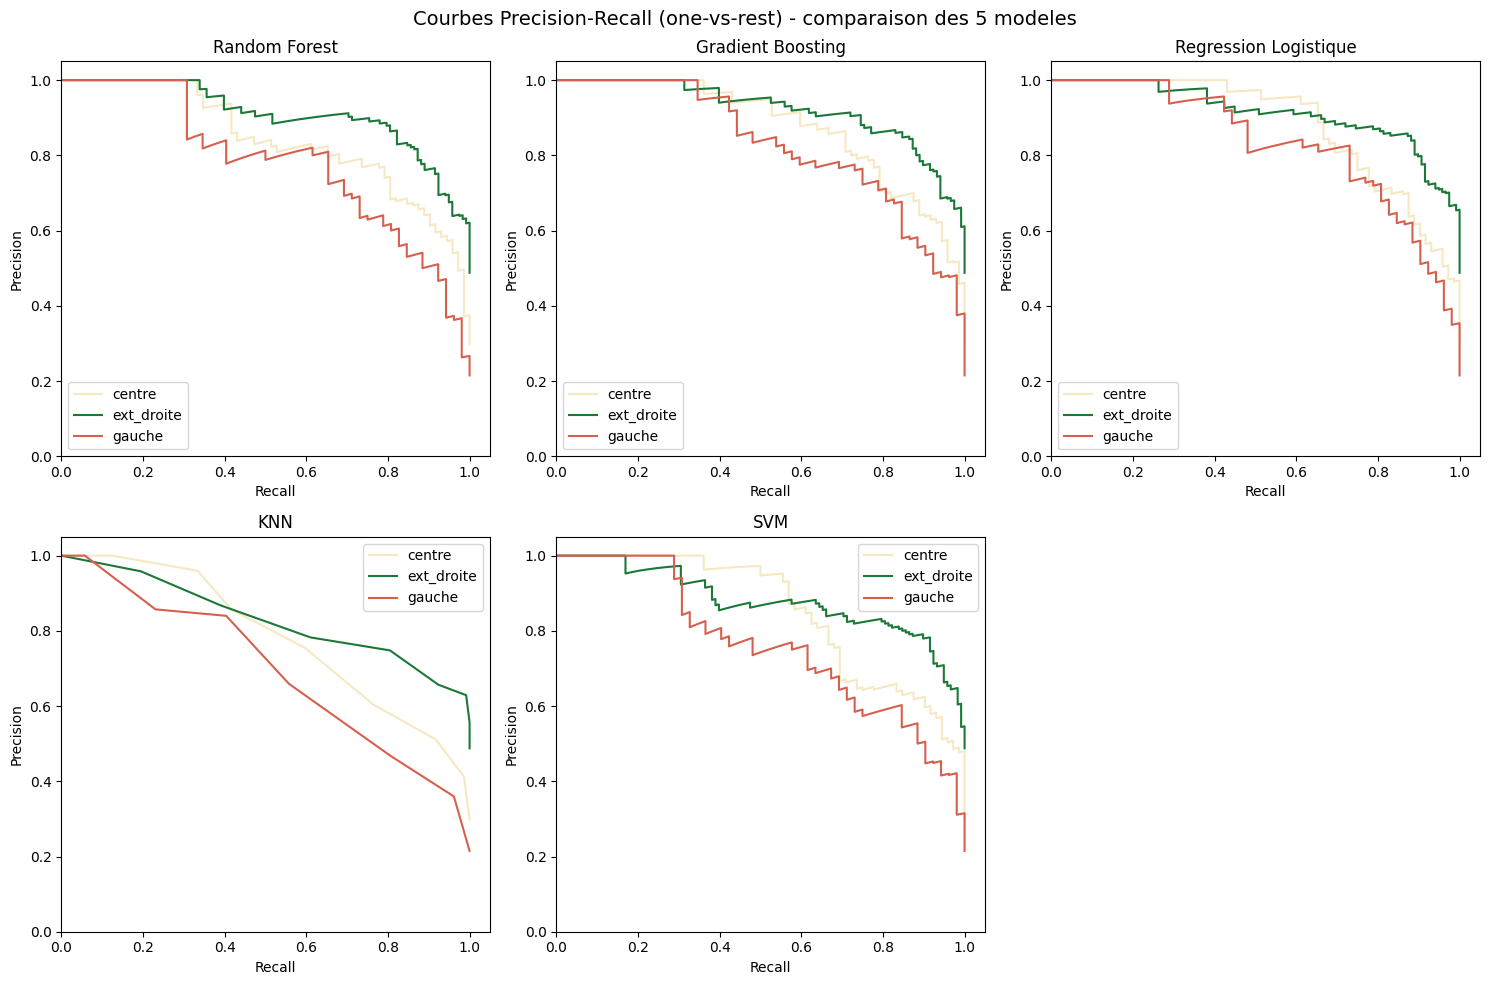

In [10]:
# ============================================================
# COURBES PRECISION-RECALL - LES 5 MODELES
# ============================================================
# Pour chaque modele et chaque classe, la courbe precision-
# recall montre le compromis entre precision (parmi les
# predictions positives, combien sont correctes) et recall
# (parmi les vrais positifs, combien sont retrouves), pour
# differents seuils de decision.
#
# One-vs-Rest : chaque classe est traitee comme "positive vs
# le reste", a partir des probabilites predict_proba().
#
# Une courbe proche du coin haut-droit (precision=1, recall=1)
# indique une bonne separation de cette classe par le modele.
# ============================================================

from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_enc, classes=[0, 1, 2])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

COULEURS_CLASSES = {0: '#f6e8c3', 1: '#1b7837', 2: '#d6604d'}  # centre, ext_droite, gauche

for i, (name, res) in enumerate(results.items()):
    model = res['model']
    if not hasattr(model, "predict_proba"):
        axes[i].text(0.5, 0.5, "predict_proba non disponible", ha='center', va='center')
        axes[i].set_title(name)
        continue

    y_proba = model.predict_proba(X_test_scaled)

    for classe_idx in range(3):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, classe_idx], y_proba[:, classe_idx])
        axes[i].plot(recall, precision, label=le.classes_[classe_idx], color=COULEURS_CLASSES[classe_idx])

    axes[i].set_title(name)
    axes[i].set_xlabel("Recall")
    axes[i].set_ylabel("Precision")
    axes[i].legend()
    axes[i].set_xlim(0, 1.05)
    axes[i].set_ylim(0, 1.05)

axes[-1].axis('off')

plt.suptitle("Courbes Precision-Recall (one-vs-rest) - comparaison des 5 modeles", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES + "09_precision_recall.png", dpi=150)
plt.show()

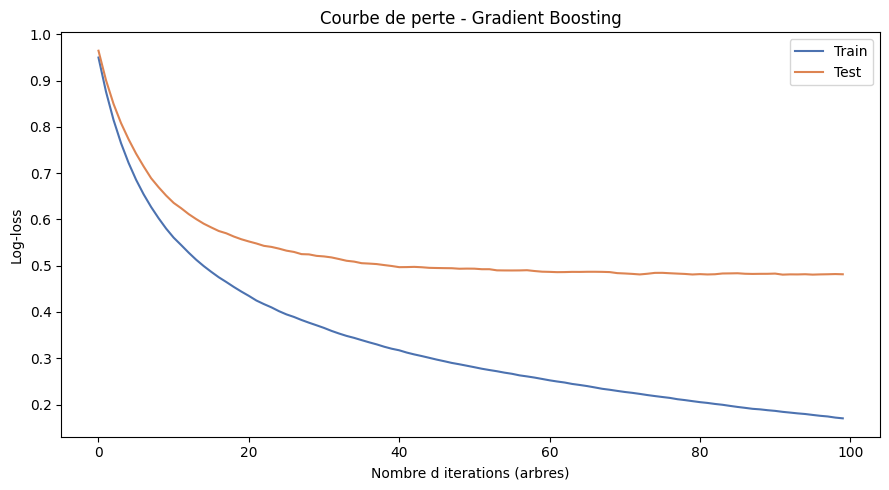

Loss finale train : 0.1702
Loss finale test  : 0.4815
Loss test minimale : 0.4807 a l iteration 92


In [11]:
# ============================================================
# COURBE DE PERTE (LOSS) - GRADIENT BOOSTING
# ============================================================
# Gradient Boosting est le seul modele entraine de facon
# iterative (ajout successif d arbres) : a chaque iteration,
# on peut mesurer la perte (deviance/log-loss) sur le train
# ET sur le test via staged_predict_proba().
#
# Lecture :
#  - La perte train doit decroitre regulierement.
#  - Si la perte test re-augmente apres un certain nombre
#    d iterations, c est un signe de surapprentissage : le
#    nombre optimal d arbres serait celui ou la perte test
#    est minimale.
# ============================================================

from sklearn.metrics import log_loss

gb_model = results['Gradient Boosting']['model']

train_losses = []
test_losses = []

for y_proba_train, y_proba_test in zip(
    gb_model.staged_predict_proba(X_train_scaled),
    gb_model.staged_predict_proba(X_test_scaled)
):
    train_losses.append(log_loss(y_train_enc, y_proba_train, labels=[0, 1, 2]))
    test_losses.append(log_loss(y_test_enc, y_proba_test, labels=[0, 1, 2]))

plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Train', color='#4C72B0')
plt.plot(test_losses, label='Test', color='#DD8452')
plt.xlabel("Nombre d iterations (arbres)")
plt.ylabel("Log-loss")
plt.title("Courbe de perte - Gradient Boosting")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES + "10_loss_curve_gb.png", dpi=150)
plt.show()

print(f"Loss finale train : {train_losses[-1]:.4f}")
print(f"Loss finale test  : {test_losses[-1]:.4f}")
print(f"Loss test minimale : {min(test_losses):.4f} a l iteration {np.argmin(test_losses)+1}")

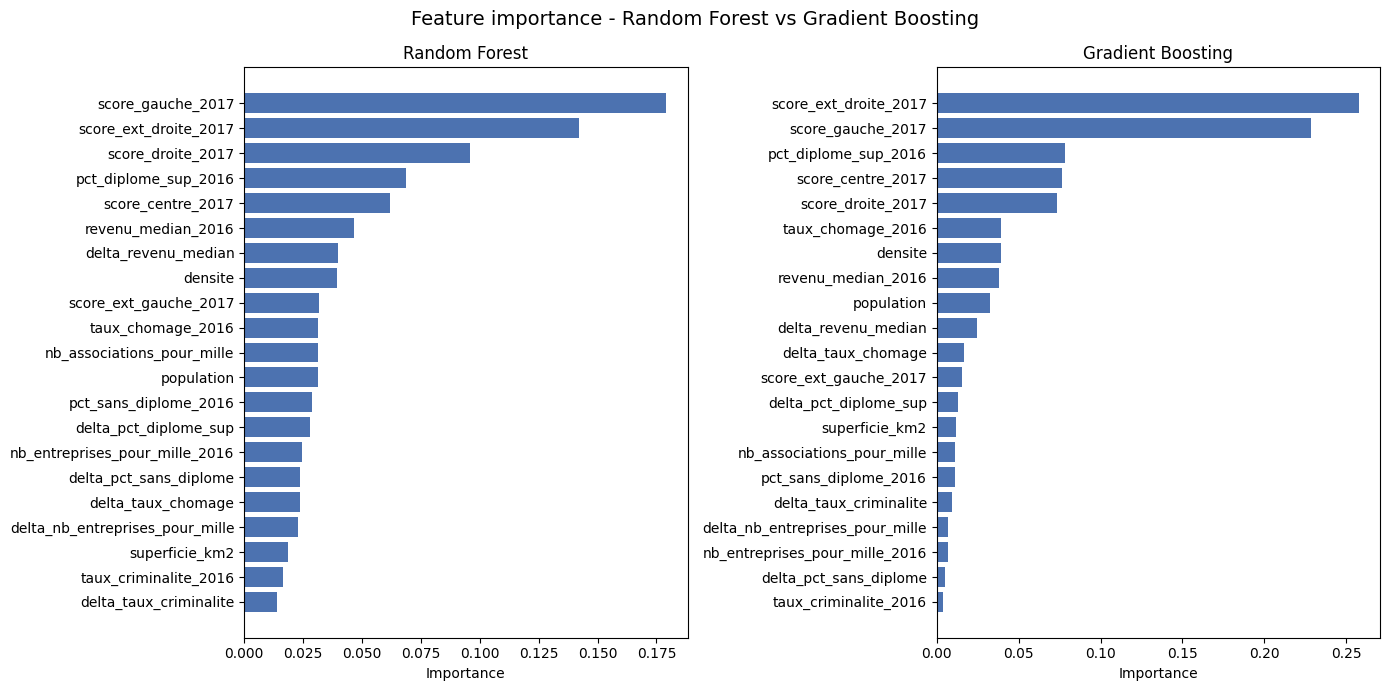

In [12]:
# ============================================================
# FEATURE IMPORTANCE - RANDOM FOREST ET GRADIENT BOOSTING
# ============================================================
# Les modeles a base d arbres exposent nativement
# feature_importances_, qui mesure la contribution de chaque
# variable a la reduction d impurete (Gini) dans les arbres.
#
# Objectif : identifier quelles variables pesent le plus dans
# les decisions du modele, et verifier la coherence avec les
# conclusions de l analyse exploratoire (revenu_median,
# pct_diplome_sup...).
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = results[name]['model']
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

    ax.barh(importances.index, importances.values, color='#4C72B0')
    ax.set_title(name)
    ax.set_xlabel("Importance")

plt.suptitle("Feature importance - Random Forest vs Gradient Boosting", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES + "11_feature_importance.png", dpi=150)
plt.show()

                       Accuracy (test)  F1 macro (test)  F1 weighted (test)  \
Modele                                                                        
Random Forest                    0.789            0.767               0.786   
Gradient Boosting                0.802            0.784               0.800   
Regression Logistique            0.789            0.785               0.790   
KNN                              0.715            0.675               0.704   
SVM                              0.702            0.691               0.706   

                       Accuracy (train)  CV mean  CV std  Ecart train-CV  
Modele                                                                    
Random Forest                     0.998    0.765   0.018           0.233  
Gradient Boosting                 0.977    0.755   0.031           0.222  
Regression Logistique             0.771    0.744   0.011           0.027  
KNN                               0.785    0.693   0.027           0.09

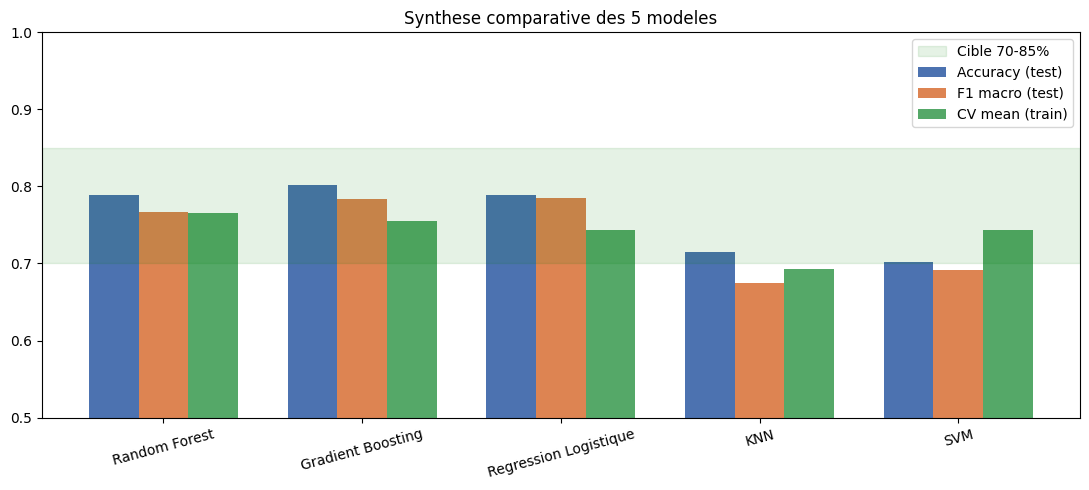

In [13]:
# ============================================================
# SYNTHESE FINALE - CHOIX DU MODELE
# ============================================================
# On rassemble toutes les metriques dans un tableau recapitulatif :
#  - Accuracy et F1 (test)
#  - Accuracy train (pour mesurer l ecart train/CV = surapprentissage)
#  - CV mean/std (stabilite)
#
# Le "meilleur" modele n est pas forcement celui avec la
# meilleure accuracy brute : on privilegie un bon compromis
# entre performance et generalisation (ecart train/CV faible,
# CV stable).
# ============================================================

synthese = []

for name, res in results.items():
    train_acc = res['model'].score(X_train_scaled, y_train_enc)
    ecart = train_acc - res['cv_mean']

    synthese.append({
        'Modele': name,
        'Accuracy (test)': res['accuracy'],
        'F1 macro (test)': res['f1_macro'],
        'F1 weighted (test)': res['f1_weighted'],
        'Accuracy (train)': train_acc,
        'CV mean': res['cv_mean'],
        'CV std': res['cv_std'],
        'Ecart train-CV': ecart,
    })

synthese_df = pd.DataFrame(synthese).set_index('Modele').round(3)
print(synthese_df)

# Visualisation
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(synthese_df))
width = 0.25

ax.bar(x - width, synthese_df['Accuracy (test)'], width, label='Accuracy (test)', color='#4C72B0')
ax.bar(x, synthese_df['F1 macro (test)'], width, label='F1 macro (test)', color='#DD8452')
ax.bar(x + width, synthese_df['CV mean'], width, label='CV mean (train)', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(synthese_df.index, rotation=15)
ax.set_ylim(0.5, 1.0)
ax.axhspan(0.70, 0.85, alpha=0.1, color='green', label='Cible 70-85%')
ax.legend()
ax.set_title("Synthese comparative des 5 modeles")
plt.tight_layout()
plt.savefig(FIGURES + "12_synthese_modeles.png", dpi=150)
plt.show()

In [14]:
# ============================================================
# APPLICATION DU MODELE FINAL (REGRESSION LOGISTIQUE)
# ============================================================
# On applique le modele final aux 1207 communes (standardisees
# avec le meme scaler que pour l entrainement) pour obtenir,
# pour chaque commune, la probabilite predite de chaque classe
# (centre, ext_droite, gauche) ainsi que la classe predite.
#
# Ces predictions servent de base aux 3 visuels de scenarios
# demandes par le CDC (diagramme de probabilite, carte de
# chaleur, courbes temporelles).
#
# NOTE : appliquer le modele a l ensemble (train+test) est
# acceptable ici car l objectif est illustratif (visualiser
# la methodologie de scenarios), pas une nouvelle evaluation
# de performance (qui reste celle mesuree sur le test, etape
# precedente).
# ============================================================

modele_final = results['Regression Logistique']['model']

X_full = dataset_final[FEATURES]
X_full_scaled = scaler.transform(X_full)

proba_full = modele_final.predict_proba(X_full_scaled)
pred_full  = modele_final.predict(X_full_scaled)

scenarios = dataset_final[['code_insee', 'nom_commune', 'gagnant_2017', 'gagnant_2022']].copy()
scenarios['prediction'] = le.inverse_transform(pred_full)

for i, classe in enumerate(le.classes_):
    scenarios[f'proba_{classe}'] = proba_full[:, i]

print(scenarios.shape)
print(scenarios.head())
print()
print("Repartition des predictions :")
print(scenarios['prediction'].value_counts())

(1207, 8)
  code_insee          nom_commune gagnant_2017 gagnant_2022  prediction  \
0      22001             Allineuc   ext_droite   ext_droite  ext_droite   
1      22002                Andel       centre       centre      centre   
2      22003             Aucaleuc       gauche   ext_droite  ext_droite   
3      22004               Bégard       gauche   ext_droite      gauche   
4      22005  Belle-Isle-en-Terre       gauche       gauche      gauche   

   proba_centre  proba_ext_droite  proba_gauche  
0      0.365470          0.630930      0.003599  
1      0.974283          0.019763      0.005954  
2      0.008940          0.770019      0.221041  
3      0.006953          0.285408      0.707639  
4      0.003815          0.228539      0.767646  

Repartition des predictions :
prediction
ext_droite    514
centre        388
gauche        305
Name: count, dtype: int64


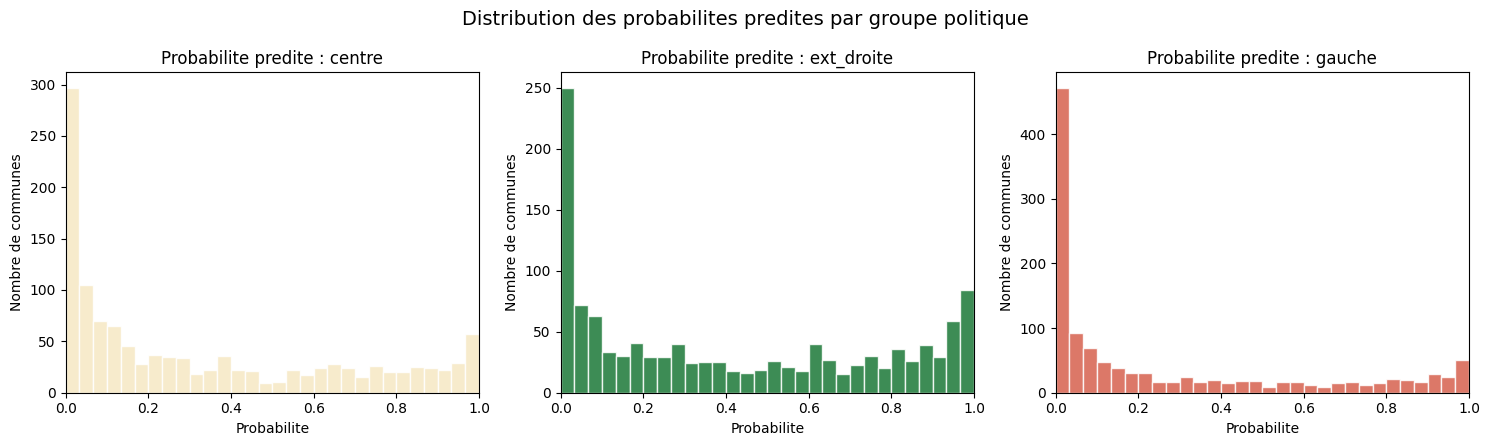

Confiance moyenne (probabilite de la classe predite) :
count    1207.000000
mean        0.776302
std         0.168943
min         0.349819
25%         0.633296
50%         0.803481
75%         0.933438
max         1.000000
dtype: float64


In [15]:
# ============================================================
# DIAGRAMME DE PROBABILITE - DISTRIBUTION DES PROBABILITES PREDITES
# ============================================================
# Pour chaque groupe politique, on affiche la distribution des
# probabilites predites par le modele sur les 1207 communes.
#
# Lecture :
#  - Une distribution bimodale (pics pres de 0 et pres de 1)
#    indique que le modele est generalement confiant (peu de
#    communes "incertaines").
#  - Une distribution concentree au centre (~0.33-0.5)
#    indiquerait au contraire beaucoup d incertitude.
#
# C est le type de visuel "diagramme de probabilite" demande
# par le CDC pour illustrer les scenarios predictifs.
# ============================================================

COULEURS_GROUPES = {
    'ext_gauche' : '#762a83',
    'gauche'     : '#d6604d',
    'centre'     : '#f6e8c3',
    'droite'     : '#92c5de',
    'ext_droite' : '#1b7837',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, classe in zip(axes, le.classes_):
    ax.hist(scenarios[f'proba_{classe}'], bins=30, color=COULEURS_GROUPES[classe], edgecolor='white', alpha=0.85)
    ax.set_title(f"Probabilite predite : {classe}")
    ax.set_xlabel("Probabilite")
    ax.set_ylabel("Nombre de communes")
    ax.set_xlim(0, 1)

plt.suptitle("Distribution des probabilites predites par groupe politique", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES + "13_diagramme_probabilite.png", dpi=150)
plt.show()

print("Confiance moyenne (probabilite de la classe predite) :")
proba_predite = scenarios[[f'proba_{c}' for c in le.classes_]].max(axis=1)
print(proba_predite.describe())

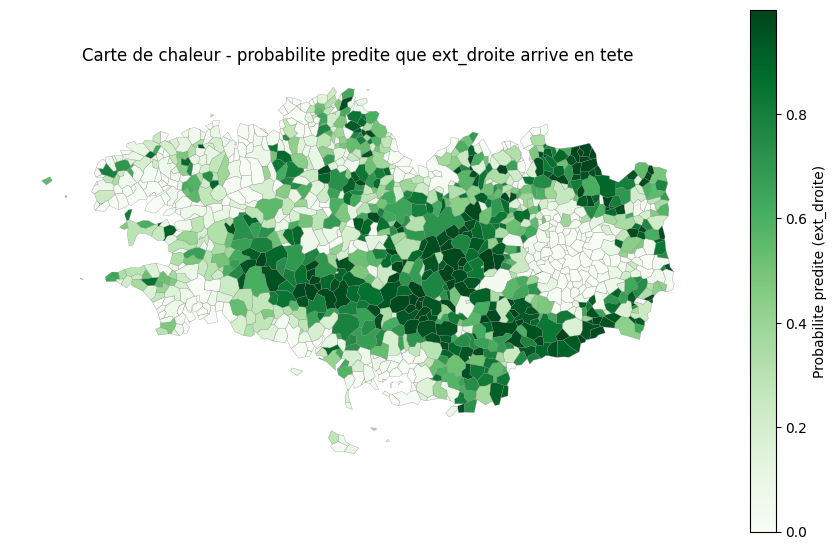

In [16]:
# ============================================================
# CARTE DE CHALEUR - PROBABILITE PREDITE 'EXT_DROITE' PAR COMMUNE
# ============================================================
# Contrairement a la carte categorielle de l EDA (1 couleur =
# 1 gagnant), cette carte de chaleur utilise une echelle
# continue : plus une commune est foncee, plus le modele lui
# attribue une forte probabilite que ext_droite y arrive en tete.
#
# Objectif : visualiser non seulement QUI le modele predit
# comme gagnant, mais aussi a quel point il en est CONFIANT,
# commune par commune - exactement le type de "carte de
# chaleur" demande par le CDC pour les scenarios predictifs.
# ============================================================

import geopandas as gpd

DEPTS_BRETAGNE = ['22', '29', '35', '56']

geo = gpd.read_file(RAW + "communes-bretagne.geojson")
geo = geo.rename(columns={'code': 'code_insee'})
geo['code_insee'] = geo['code_insee'].astype(str).str.zfill(5)
geo['departement'] = geo['departement'].astype(str).str.zfill(2)
geo = geo[geo['departement'].isin(DEPTS_BRETAGNE)].copy()

geo_proba = geo.merge(scenarios[['code_insee', 'proba_ext_droite']], on='code_insee', how='left')

fig, ax = plt.subplots(figsize=(9, 9))
geo_proba.plot(
    column='proba_ext_droite', ax=ax, cmap='Greens',
    edgecolor='grey', linewidth=0.2, legend=True,
    legend_kwds={'label': "Probabilite predite (ext_droite)", 'shrink': 0.6}
)
ax.set_title("Carte de chaleur - probabilite predite que ext_droite arrive en tete")
ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES + "14_carte_chaleur_proba_ext_droite.png", dpi=150)
plt.show()

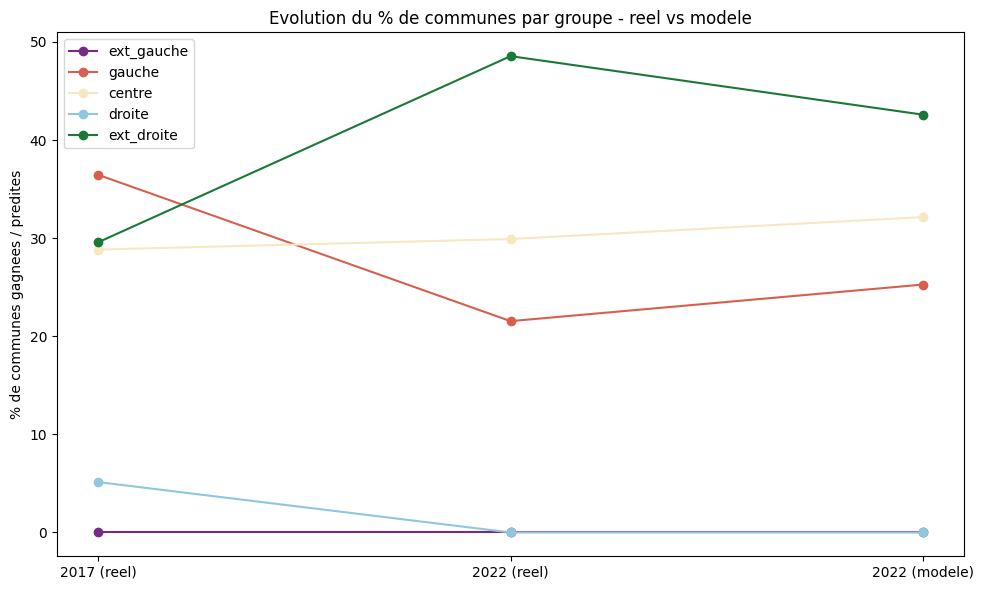

2017 reel   : {'gauche': 36.5, 'ext_droite': 29.6, 'centre': 28.8, 'droite': 5.1}
2022 reel   : {'ext_droite': 48.6, 'centre': 29.9, 'gauche': 21.5}
2022 modele : {'ext_droite': 42.6, 'centre': 32.1, 'gauche': 25.3}


In [17]:
# ============================================================
# COURBES TEMPORELLES - % DE COMMUNES GAGNEES/PREDITES
# ============================================================
# Pour assurer une comparaison coherente (meme grandeur sur
# les 3 points), on utilise le % de communes gagnees/predites
# par groupe, sur les 1207 communes communes aux 2 annees :
#  - 2017 (reel)   : gagnant_2017
#  - 2022 (reel)   : gagnant_2022
#  - 2022 (modele) : prediction du modele final
#
# Les 3 points representent ainsi la MEME grandeur (% de
# communes), ce qui rend la courbe directement interpretable :
# elle illustre la tendance electorale observee (2017->2022)
# et la capacite du modele a la retrouver.
#
# ext_gauche et droite n apparaissent jamais comme gagnant en
# 2022 ni en prediction (0%), ce qui est attendu (cf. EDA).
# ============================================================

n = len(dataset_final)

pct_2017 = (dataset_final['gagnant_2017'].value_counts() / n * 100)
pct_2022 = (dataset_final['gagnant_2022'].value_counts() / n * 100)
pct_modele = (scenarios['prediction'].value_counts() / n * 100)

GROUPES_ORDRE = ['ext_gauche', 'gauche', 'centre', 'droite', 'ext_droite']

fig, ax = plt.subplots(figsize=(10, 6))
x_labels = ['2017 (reel)', '2022 (reel)', '2022 (modele)']
x_pos = [0, 1, 2]

for groupe in GROUPES_ORDRE:
    y_vals = [
        pct_2017.get(groupe, 0),
        pct_2022.get(groupe, 0),
        pct_modele.get(groupe, 0),
    ]
    ax.plot(x_pos, y_vals, 'o-', label=groupe, color=COULEURS_GROUPES[groupe])

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel("% de communes gagnees / predites")
ax.set_title("Evolution du % de communes par groupe - reel vs modele")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES + "15_courbes_temporelles.png", dpi=150)
plt.show()

print("2017 reel   :", pct_2017.round(1).to_dict())
print("2022 reel   :", pct_2022.round(1).to_dict())
print("2022 modele :", pct_modele.round(1).to_dict())

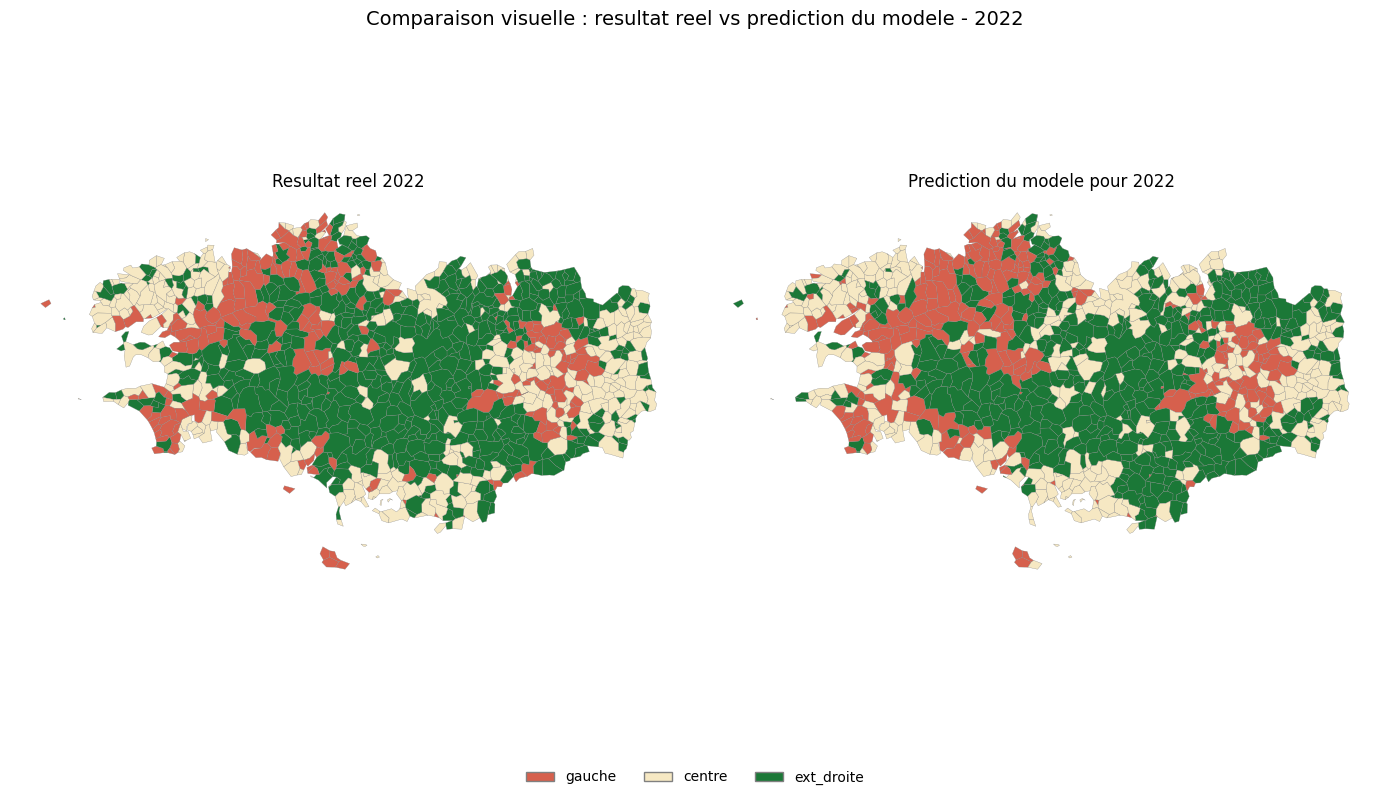

Taux de concordance (1207 communes, illustratif) : 0.775
Rappel - accuracy officielle (242 communes test, jamais vues) : 0.789


In [18]:
# ============================================================
# CARTE COMPARATIVE - RESULTAT REEL 2022 vs PREDICTION DU MODELE
# ============================================================
# Meme principe que la carte EDA (2017 vs 2022), mais ici on
# compare, pour 2022, le resultat REEL (gagnant_2022) et le
# resultat PREDIT par le modele (prediction), commune par
# commune - avec le meme code couleur que dans l EDA.
#
# NOTE IMPORTANTE : cette carte est realisee sur les 1207
# communes (train+test confondus), donc le taux de concordance
# visible ici est superieur a l accuracy officielle du modele
# (0.789, mesuree uniquement sur les 242 communes de test
# jamais vues pendant l entrainement). Cette carte est
# illustrative (vision d ensemble), l accuracy de reference
# pour evaluer le modele reste celle du test.
# ============================================================

from matplotlib.patches import Patch

geo_compare = geo.merge(
    scenarios[['code_insee', 'gagnant_2022', 'prediction']],
    on='code_insee', how='left'
)
geo_compare['couleur_reel']    = geo_compare['gagnant_2022'].map(COULEURS_GROUPES).fillna('#cccccc')
geo_compare['couleur_predit']  = geo_compare['prediction'].map(COULEURS_GROUPES).fillna('#cccccc')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

geo_compare.plot(ax=axes[0], color=geo_compare['couleur_reel'], edgecolor='grey', linewidth=0.2)
axes[0].set_title("Resultat reel 2022")
axes[0].axis('off')

geo_compare.plot(ax=axes[1], color=geo_compare['couleur_predit'], edgecolor='grey', linewidth=0.2)
axes[1].set_title("Prediction du modele pour 2022")
axes[1].axis('off')

legend_elements = [
    Patch(facecolor=c, edgecolor='grey', label=g)
    for g, c in COULEURS_GROUPES.items() if g in ['centre', 'gauche', 'ext_droite']
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, frameon=False)

plt.suptitle("Comparaison visuelle : resultat reel vs prediction du modele - 2022", fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(FIGURES + "16_carte_reel_vs_predit.png", dpi=150)
plt.show()

# Taux de concordance global (illustratif, train+test)
concordance = (scenarios['gagnant_2022'] == scenarios['prediction']).mean()
print(f"Taux de concordance (1207 communes, illustratif) : {concordance:.3f}")
print(f"Rappel - accuracy officielle (242 communes test, jamais vues) : {results['Regression Logistique']['accuracy']:.3f}")

1 an (facteur x1.2) - ecart max vs original : 1087.20
2 ans (facteur x1.4) - ecart max vs original : 2174.40
3 ans (facteur x1.6) - ecart max vs original : 3261.60

Probabilite moyenne predite par horizon :
  2022 (modele)   : {'centre': 32.8, 'ext_droite': 41.1, 'gauche': 26.2}
  1 an            : {'centre': 35.0, 'ext_droite': 39.6, 'gauche': 25.4}
  2 ans           : {'centre': 37.2, 'ext_droite': 38.2, 'gauche': 24.6}
  3 ans           : {'centre': 39.5, 'ext_droite': 36.7, 'gauche': 23.8}


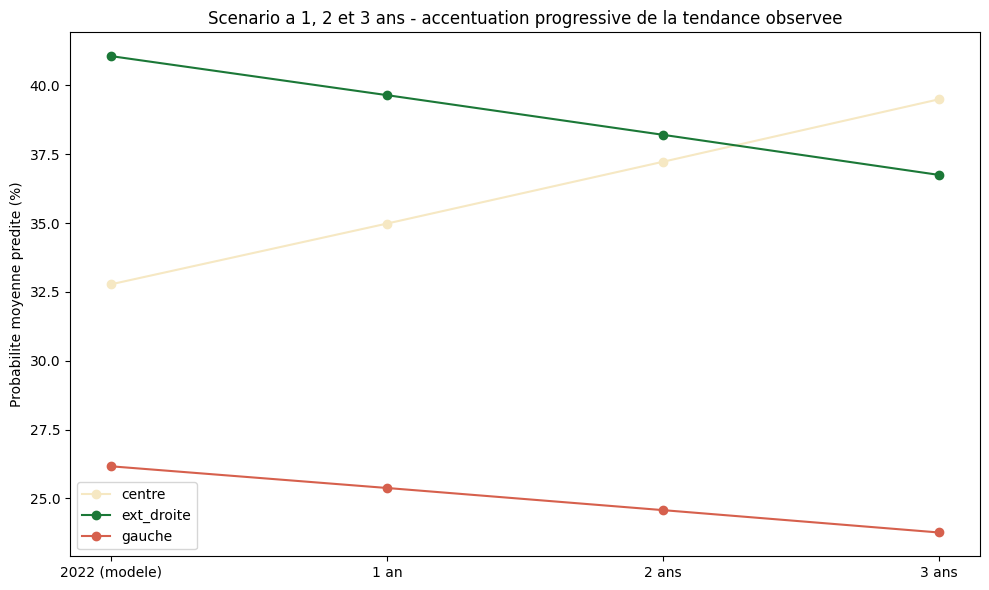

In [22]:
# ============================================================
# PROJECTION A 1, 2 ET 3 ANS - SIMULATION DE SENSIBILITE
# ============================================================
# Plutot que de changer la base temporelle (qui produit une
# extrapolation hors distribution, instable - cf. tentatives
# precedentes), cette version garde TOUTES les features
# d origine identiques (indicateurs 2016, scores 2017) et fait
# seulement varier l intensite du delta (tendance observee),
# en restant proche des valeurs vues a l entrainement.
#
# Hypothese : +1 an = la tendance 2016->2021 s accentue de 20%,
# +2 ans = +40%, +3 ans = +60%. Ce facteur reste modere pour
# eviter de sortir de la plage de valeurs connue du modele.
#
# Cette approche repond a la demande du CDC (visualiser un
# scenario a 1/2/3 ans) tout en restant dans le domaine de
# validite du modele, contrairement a une reprojection complete
# de la base temporelle.
# ============================================================

proba_modele = {classe: scenarios[f'proba_{classe}'].mean() * 100 for classe in le.classes_}

facteurs = {'1 an': 1.2, '2 ans': 1.4, '3 ans': 1.6}
proba_horizons = {}

for label, facteur in facteurs.items():
    X_projete = dataset_final[FEATURES].copy()

    for ind in INDICATEURS_EVOLUTIFS:
        X_projete[f'delta_{ind}'] = dataset_final[f'delta_{ind}'] * facteur

    X_projete_scaled = scaler.transform(X_projete[FEATURES])
    proba_horizon = modele_final.predict_proba(X_projete_scaled)

    proba_horizons[label] = {classe: proba_horizon[:, i].mean() * 100 for i, classe in enumerate(le.classes_)}

    # Verification : on reste dans une plage raisonnable vs entrainement
    ecart_max = (X_projete[FEATURES] - dataset_final[FEATURES]).abs().max().max()
    print(f"{label} (facteur x{facteur}) - ecart max vs original : {ecart_max:.2f}")

proba_horizons_complet = {'2022 (modele)': proba_modele, **proba_horizons}

print("\nProbabilite moyenne predite par horizon :")
for horizon, probas in proba_horizons_complet.items():
    print(f"  {horizon:15s} : { {k: round(v,1) for k,v in probas.items()} }")

fig, ax = plt.subplots(figsize=(10, 6))
x_labels = list(proba_horizons_complet.keys())
x_pos = range(len(x_labels))

for classe in le.classes_:
    y_vals = [proba_horizons_complet[h][classe] for h in x_labels]
    ax.plot(x_pos, y_vals, 'o-', label=classe, color=COULEURS_GROUPES[classe])

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_ylabel("Probabilite moyenne predite (%)")
ax.set_title("Scenario a 1, 2 et 3 ans - accentuation progressive de la tendance observee")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES + "17_projection_1_2_3_ans.png", dpi=150)
plt.show()